# Netflix Catalog Analytics 



## Part 1️⃣: Theoretical & Conceptual Formulations (15 Questions)

### <span style="color:#00D2FF;">Q1. Discuss the memory allocation differences between a Pandas DataFrame column stored as an object (string) versus a category. In what scenarios does categorical conversion degrade performance?</span>

*   **Memory Allocation**: An `object` column stores full Python string objects (or pointers to them) for every single row, duplicating memory for repeating strings. A `category` column builds a single internal dictionary array of unique strings, then replaces each row's values with lightweight integer pointers (e.g., `int8`, `int16`) targeting that dictionary, drastically dropping memory usage.
*   **Performance Degradation**: Categorical conversion degrades performance in **high-cardinality columns** where almost every row contains a unique string (e.g., UUIDs, timestamps, unique names). The computational overhead of managing, hashing, and searching a massive unique dictionary index outweighs the memory benefits, slowing down operations like sorting, grouping, and filtering.

---

### <span style="color:#00D2FF;">Q2. Explain the underlying mechanism of NumPy's "ufuncs" (Universal Functions). Why do they execute operations on arrays orders of magnitude faster than standard Python list comprehensions?</span>

*   **Mechanism**: NumPy `ufuncs` execute element-wise operations on arrays. They bypass the slow Python interpreter completely by running compiled, low-level C code loops over continuous, flat blocks of homogeneous memory, utilizing SIMD (Single Instruction, Multiple Data) processor architectures to compute multiple array elements in a single hardware cycle.
*   **Why Faster**: A standard Python list comprehension relies on a dynamic pointer track. For every single element, the interpreter must perform a slow loop step, inspect object wrappers, check dynamic type flags, and resolve method references, adding heavy execution overhead that `ufuncs` eliminate entirely.

---

### <span style="color:#00D2FF;">Q3. In the context of Pandas, what is the exact difference between loc[] and iloc[] indexing? Provide an edge case where using one over the other prevents a logical error?</span>

*   **Exact Difference**: `.loc[]` is strictly label-based indexing that queries row/column names or custom index tags, and its slice ranges are fully inclusive of the endpoint. `.iloc[]` is strictly integer position-based indexing that queries absolute 0-indexed layout coordinates, and its slice ranges follow standard Python rules (exclusive of the endpoint).
*   **Edge Case**: Consider a DataFrame shuffled or filtered where the index labels become non-consecutive integers like `[3, 7, 9]`. If you attempt to access the very first row using `df.loc[0]`, the system will crash with a severe `KeyError` or return an incorrect row if a label happens to match `0`. Running `df.iloc[0]` safely and predictably extracts the true first physical row of the active filtered view.

---

### <span style="color:#00D2FF;">Q4. When merging two DataFrames using pd.merge(), define the differences between an 'inner', 'outer', 'left', and 'right' join. How does Pandas handle key mismatches in a left join?</span>

*   **Join Behaviors**:
    *   **`inner`**: Keeps only the rows where the join keys match perfectly in both DataFrames.
    *   **`outer`**: Keeps all rows from both DataFrames, filling missing gaps with null values.
    *   **`left`**: Keeps every row from the left DataFrame, matching records from the right where possible.
    *   **`right`**: Keeps every row from the right DataFrame, matching records from the left where possible.
*   **Key Mismatches**: In a `left` join, if a key in the left DataFrame cannot be found anywhere within the right DataFrame's key set, Pandas populates all fields belonging to the right DataFrame with missing values (`NaN` or `None`).

---

### <span style="color:#00D2FF;">Q5. Describe the Split-Apply-Combine paradigm. How does the .groupby() object in Pandas lazily evaluate this process before an aggregation method is called?</span>

*   **Paradigm Phases**:
    1.  **Split**: Divides a dataset into isolated sub-population chunks based on specific key attributes.
    2.  **Apply**: Computes a function or statistical calculation independently on each isolated group.
    3.  **Combine**: Collapses and stitches the separate chunk outputs back into a single cohesive DataFrame structure.
*   **Lazy Evaluation**: Executing `df.groupby('key')` does not physically split or duplicate data in memory. Instead, it lazily creates a low-overhead `DataFrameGroupBy` object that maps out the row index addresses for each group category. The actual data splitting, function application, and combination steps are deferred until an active evaluation method (like `.sum()`, `.mean()`, or `.agg()`) is explicitly executed.

---

### <span style="color:#00D2FF;">Q6. What is the specific purpose of the .transform() method on a Pandas GroupBy object, and how does its returned shape differ from that of .agg()?</span>

*   **Purpose**: `.transform()` applies a summary or transformation operation across individual groups independently, but broadcasts the resulting values back onto the row indices of the original dataset.
*   **Shape Difference**: While `.agg()` reduces data density by collapsing individual rows to return exactly one summary row per unique group category, `.transform()` always returns an output structure that matches the exact row count and layout shape of the original input DataFrame.

---

### <span style="color:#00D2FF;">Q7. Explain how Kernel Density Estimation (KDE) is calculated in statistical plotting. What role does the "bandwidth" parameter play in smoothing the distribution?</span>

*   **Calculation**: KDE calculates a smooth, continuous probability density curve over an active distribution. It works by placing a small, continuous probability curve (a kernel, usually a normal/Gaussian distribution) over every single independent data point in the set, then summing all these individual curves together to produce a single master distribution line.
*   **Bandwidth Role**: The bandwidth parameter controls the width of those individual kernel curves. A **small bandwidth** makes the kernels narrow, overfitting the line to individual data entries and producing a jagged, noisy curve. A **large bandwidth** makes the kernels very wide, oversmoothing the curve and flattening out real structural peaks or variations in the dataset.

---

### <span style="color:#00D2FF;">Q8. When visualizing multivariate data, what are the distinct advantages of a Seaborn violinplot compared to a standard boxplot?</span>

*   **Violinplot Advantages**: A boxplot only displays static summary statistics (quartiles, median, and outliers), completely hiding the true distribution shape between those points. A violinplot includes these summary metrics but wraps them inside a continuous Kernel Density Estimation curve. This reveals vital hidden distribution structures, such as multiple distinct peaks (multimodal patterns), skewness, or internal data clustering that a flat boxplot cannot show.

---

### <span style="color:#00D2FF;">Q9. Define "Multicollinearity". How would you utilize a Pandas correlation matrix combined with a Seaborn heatmap to identify it prior to training a machine learning model?</span>

*   **Definition**: Multicollinearity is a condition where two or more independent features in a dataset are highly correlated with each other, meaning they provide redundant information.
*   **Identification Strategy**: Run `df.corr(method='pearson')` to build a numeric cross-correlation matrix tracking all features, then pass that matrix directly into `sns.heatmap(annot=True, cmap='coolwarm', vmin=-1, vmax=1)`. By reviewing the color-coded matrix grids, you can immediately target highly correlated feature intersections (typically values $> 0.80$ or $< -0.80$) and safely drop the redundant columns before training.

---

### <span style="color:#00D2FF;">Q10. Discuss the difference between Matplotlib's "State-based" interface (pyplot) and its "Object Oriented" interface (Figures and Axes). Why is the latter preferred in advanced workflows?</span>

*   **Difference**: The state-based interface (`plt.plot()`) implicitly tracks figures and subplots automatically behind the scenes, applying adjustments to whichever plot was called last. The object-oriented interface explicitly generates independent canvas object instances for the total container figure (`fig`) and the target plot grids (`ax`).
*   **Why Preferred**: The object-oriented approach is preferred for complex graphics because it provides absolute control over individual plot elements. You can modify, resize, or draw across specific subplots simultaneously by directly accessing their individual `ax` references, completely avoiding the risk of accidental crossover or canvas contamination.

---

### <span style="color:#00D2FF;">Q11. What is "broadcasting" in NumPy? State the rules that determine if two multidimensional arrays with different shapes can be broadcast together.</span>

*   **Broadcasting**: Broadcasting is a performance mechanism that allows arithmetic operations to be performed between arrays of different shapes without explicit looping or memory-intensive data copying.
*   **Rules for Compatibility**: NumPy evaluates array dimensions from right to left (**trailing dimensions first**). Two dimensions are fully compatible if:
    1.  The dimensions are exactly equal in size.
    2.  One of the dimensions is exactly `1`. If a dimension is `1`, it is virtually stretched to match the larger size.

---

### <span style="color:#00D2FF;">Q12. When processing text data, explain the performance implications of using Pandas' .str accessor methods versus applying a custom regex-compiled lambda function using .apply().</span>

*   **Performance Implications**: Pandas `.str` accessors are highly optimized vector wrappers that call efficient C-level string operations over series blocks. Conversely, passing a custom regex-compiled lambda function via `.apply(lambda x: re.search(..., x))` triggers a heavy Python-level loop. This forces the interpreter to constantly unpack data, create individual string object instances, and apply the lambda logic row-by-row, which is significantly slower for large text datasets.

---

### <span style="color:#00D2FF;">Q13. What is the Interquartile Range (IQR)? Describe how it is mathematically derived and how it is visually represented within a boxplot.</span>

*   **Mathematical Derivation**: The Interquartile Range measures statistical dispersion, calculated as the difference between the 75th percentile ($Q_3$) and the 25th percentile ($Q_1$):
    $$IQR = Q_3 - Q_1$$
*   **Visual Representation**: In a standard boxplot, the IQR forms the central **box body** container (spanning from the lower edge $Q_1$ to the upper edge $Q_3$), capturing the middle 50% of the distribution. The line splitting the interior of the box represents the median ($Q_2$).

---

### <span style="color:#00D2FF;">Q14. Describe the mechanism and use case of Pandas' .explode() method. How does the index behave after an explosion operation?</span>

*   **Mechanism & Use Case**: `.explode()` transforms each element of a list-like structure into a separate, independent row. It is used when a single cell contains grouped data arrays (like lists or comma-separated tags) and you need to flatten those arrays into tidy data format.
*   **Index Behavior**: The original index labels are fully preserved and duplicated across the newly generated rows. If a row with index `5` contains a list of 3 items, the resulting DataFrame will feature 3 independent rows all sharing the exact index label `5`.

---

### <span style="color:#00D2FF;">Q15. In time-series data handling, what does the process of "Resampling" involve in Pandas, and how does it differ from a standard groupby operation?</span>

*   **Resampling Process**: Resampling involve converting a time-series dataset from one specific date/time frequency to another. It includes **downsampling** (aggregating high-frequency data, like hourly logs to daily sums) and **upsampling** (interpolating low-frequency data to a higher frequency, like monthly records to daily rows using fill methods).
*   **Difference from Groupby**: While a standard `.groupby()` treats date elements as discrete categorical text buckets, `.resample()` utilizes a time-aware index engine. This engine understands temporal logic, automatically fills chronological calendar gaps, allows forward/backward fill interpolation (`ffill`/`bfill`), and manages custom window frequencies natively.

## Part 2️⃣: Practical Code Implementation (15 Questions)

#### THe FOUNDATION CODE

In [1]:
# --- STEP 1: IMPORT CORE PRODUCTION LIBRARIES ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set global Seaborn theme configurations for clean, consistent visuals
sns.set_theme(style="whitegrid")

# --- STEP 2: LOAD NETFLIX CATALOG SCHEMAS ---
# We explicitly define the schemas during ingestion to maximize memory savings
dtypes = {
    'show_id': 'string',
    'type': 'category',        # Low-cardinality label (Movie vs TV Show)
    'title': 'string',
    'director': 'string',
    'cast': 'string',
    'country': 'category',     # Memory optimization for repeating regional locations
    'rating': 'category',      # Fixed classification tracker codes
    'listed_in': 'category',
    'duration': 'string'
}

# Load the file directly into the master data frame instance 'df'
df = pd.read_csv('netflix_titles.csv', dtype=dtypes)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,<NA>,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,<NA>,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,<NA>,<NA>,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,<NA>,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


# 📝  Data Pipeline Foundation Summary

The setup infrastructure loads the raw Netflix catalog data using high-efficiency settings while leaving individual data formatting steps to be handled dynamically within their specific query blocks.

---

## 🛠️ Operational Breakdown

### 1. Ingestion & Resource Optimization
* **Library Activation:** Initializes the production analytics dependencies (`pandas`, `numpy`, `matplotlib`, `seaborn`) and enforces a globally unified visualization layout grid (`whitegrid`).
* **RAM Optimization:** Compresses the dataset's initial memory footprint at load time by mapping repetitive textual column fields (such as `type`, `country`, `rating`, and `listed_in`) directly to lightweight categorical indices instead of heavy `object` variables.

### 2. Localized Execution Strategy
* **Zero Overhead:** Avoids processing columns globally at ingestion, ensuring the core dataframe remains completely raw and unmanipulated initially.
* **Just-In-Time Engineering:** Defers heavier calculations—such as Regular Expression string stripping for runtimes (`duration_numeric`) and string parsing for calendar elements (`date_added`)—to execute right inside their specific cells. This makes the code self-contained and easy to follow.

---

## 📐 Pipeline Blueprint
```text
[Raw CSV File] ➡️ [Strict Categorical Mapping Only] ➡️ [Pure df Ready for Localized Tasks]

### <span style="color:#00D2FF;">Q16. Write a one-line Pandas command to find the percentage of missing values in every column of the DataFrame, sorted in descending order.</span>

In [2]:
missing_percentages = df.isnull().mean().sort_values(ascending=False) * 10
print(" Percentage of Missing Values per Column:")
print(missing_percentages)

 Percentage of Missing Values per Column:
director        2.990803
country         0.943568
cast            0.936755
date_added      0.011355
rating          0.004542
duration        0.003406
show_id         0.000000
type            0.000000
title           0.000000
release_year    0.000000
listed_in       0.000000
description     0.000000
dtype: float64


### <span style="color:#00D2FF;">Q17. Using NumPy's np.where, create a new boolean column called is_director_known that evaluates to True if the 'director' column is not null, and False otherwise.</span>

In [3]:
df['is_director_known'] = np.where(df['director'].notnull(), True, False)

print(" Director Status Flag Distribution:")
print(df[['show_id', 'director', 'is_director_known']].head(5))

 Director Status Flag Distribution:
  show_id         director  is_director_known
0      s1  Kirsten Johnson               True
1      s2             <NA>              False
2      s3  Julien Leclercq               True
3      s4             <NA>              False
4      s5             <NA>              False


### <span style="color:#00D2FF;">Q18. Write a Pandas code snippet to extract the month name from the date_added column, assuming it has already been converted to datetime type.</span>

In [4]:
# Perform localized datetime conversion before transformation
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract textual month name
df['month_added'] = df['date_added'].dt.month_name()

print("📅 Sample Rows with Extracted Month Names:")
print(df[['show_id', 'date_added', 'month_added']].dropna().head())

📅 Sample Rows with Extracted Month Names:
  show_id date_added month_added
0      s1 2021-09-25   September
1      s2 2021-09-24   September
2      s3 2021-09-24   September
3      s4 2021-09-24   September
4      s5 2021-09-24   September


### <span style="color:#00D2FF;">Q19. Assume the 'cast' column contains comma-separated names. Write the chained operations required to split this column into lists and explode it into a new DataFrame called cast_df.</span>

In [5]:
cast_df = df.assign(cast=df['cast'].str.split(', ')).explode('cast')  # .explode() takes those newly created lists inside the cast column and transforms each element into its own separate row.

print(f"💥 Explosion completed. Cast DataFrame rows expanded to: {cast_df.shape[0]}")
print(cast_df[['show_id', 'cast']].head(5))

💥 Explosion completed. Cast DataFrame rows expanded to: 64951
  show_id            cast
0      s1             NaN
1      s2      Ama Qamata
1      s2     Khosi Ngema
1      s2   Gail Mabalane
1      s2  Thabang Molaba


### <span style="color:#00D2FF;">Q20. Using the exploded cast_df, write a groupby aggregation to find the top 5 actors who have appeared in the most 'TV Show' titles.</span>

In [6]:
# Using show_id as the primary count tracking metric
top_tv_actors = cast_df[cast_df['type'] == 'TV Show'].groupby('cast')['show_id'].count().nlargest(5)

print("🏆 Top 5 Actors by TV Show Appearances:")
print(top_tv_actors)


🏆 Top 5 Actors by TV Show Appearances:
cast
Takahiro Sakurai    25
Yuki Kaji           19
Ai Kayano           17
Daisuke Ono         17
Junichi Suwabe      17
Name: show_id, dtype: int64


### <span style="color:#00D2FF;">Q21. Write the Seaborn code to generate a countplot showing the distribution of the 'rating' column, ensuring the bars are sorted by frequency (highest to lowest).</span>

C:\Users\ajayb\AppData\Local\Temp\ipykernel_13876\2185591126.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='rating', order=rating_order, palette='viridis')


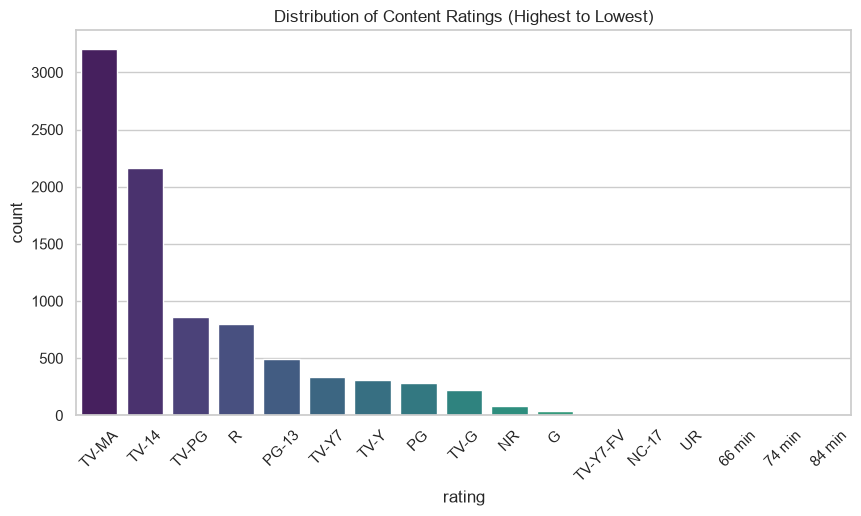

In [7]:
plt.figure(figsize=(10, 5))
rating_order = df['rating'].value_counts().index
sns.countplot(data=df, x='rating', order=rating_order, palette='viridis')

plt.title('Distribution of Content Ratings (Highest to Lowest)')
plt.xticks(rotation=45)
plt.show()

### <span style="color:#00D2FF;">Q22. Write a Pandas query to filter the DataFrame for titles released between 2015 and 2020 (inclusive) that were produced in 'India'.</span>

In [8]:
india_titles_2015_2020 = df.query("2015 <= release_year <= 2020 and country == 'India'")

print(f"🇮🇳 Found {india_titles_2015_2020.shape[0]} matching Indian titles in timeframe.")
print(india_titles_2015_2020[['show_id', 'title', 'release_year']].head(5))

🇮🇳 Found 492 matching Indian titles in timeframe.
    show_id                           title  release_year
69      s70  Stories by Rabindranath Tagore          2015
105    s106                Angamaly Diaries          2017
116    s117                          Dhanak          2015
118    s119                         Gurgaon          2017
126    s127                         Shikara          2020


### <span style="color:#00D2FF;">Q23. Using np.select, write a script to categorize 'release_year': values before 2000 as '20th Century', 2000-2010 as '2000s', and >2010 as '2010s+'.</span>

In [9]:
conditions = [
    (df['release_year'] < 2000),
    (df['release_year'] >= 2000) & (df['release_year'] <= 2010),
    (df['release_year'] > 2010)
]
choices = ['20th Century', '2000s', '2010s+']
df['era_category'] = np.select(conditions, choices, default='Unknown')

print("📊 Structural Breakdown Distribution of Categorized Eras:")
print(df['era_category'].value_counts())

📊 Structural Breakdown Distribution of Categorized Eras:
era_category
2010s+          7278
2000s           1004
20th Century     525
Name: count, dtype: int64


### <span style="color:#00D2FF;">Q24. Create a Pandas pivot table that displays the count of 'show_id', with 'rating' as the index (rows) and 'type' (Movie/TV Show) as the columns. Fill any NaNs with 0.</span>

In [11]:
# Create pivot table counting show_id per rating and type
rating_type_pivot = df.pivot_table(
    index='rating', 
    columns='type', 
    values='show_id', 
    aggfunc='count', 
    fill_value=0
)

# Display the resulting pivot matrix
print("📁 Cross-Tabular Content Matrix Reference Layout:")
print(rating_type_pivot)

📁 Cross-Tabular Content Matrix Reference Layout:
type      Movie  TV Show
rating                  
66 min        1        0
74 min        1        0
84 min        1        0
G            41        0
NC-17         3        0
NR           75        5
PG          287        0
PG-13       490        0
R           797        2
TV-14      1427      733
TV-G        126       94
TV-MA      2062     1145
TV-PG       540      323
TV-Y        131      176
TV-Y7       139      195
TV-Y7-FV      5        1
UR            3        0


### <span style="color:#00D2FF;">Q25. Write Matplotlib Object-Oriented code (using fig, ax = plt.subplots(1, 2)) to plot a histogram of 'release_year' on the left axis, and a histogram of 'duration_numeric' (for movies) on the right axis.</span>

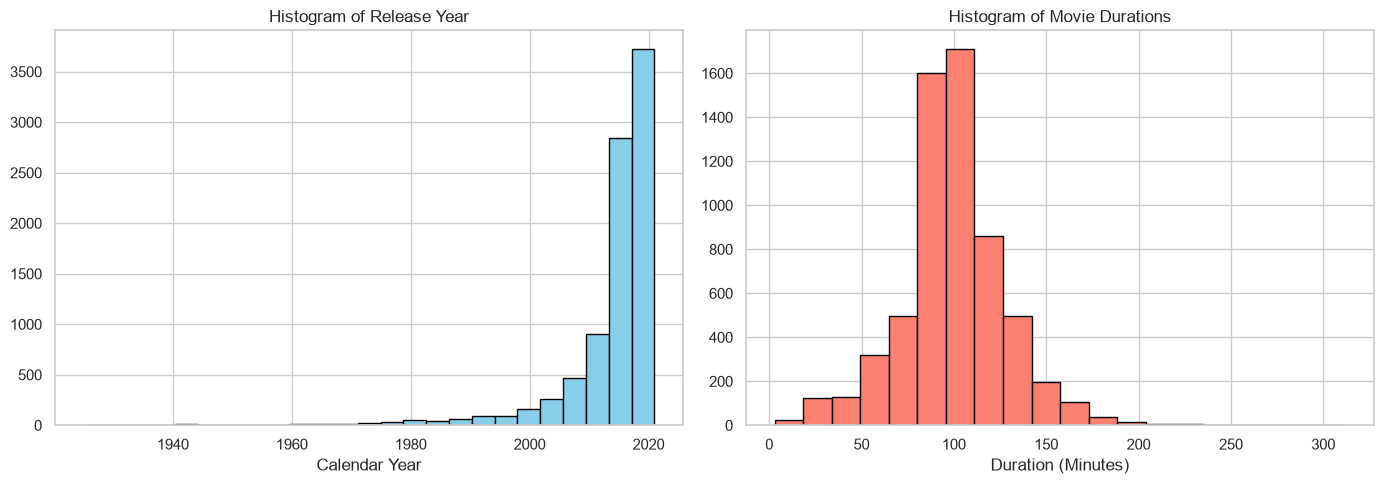

In [12]:
# Perform localized text extraction to create numeric field
df['duration_numeric'] = df['duration'].str.extract(r'(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot left histogram
axes[0].hist(df['release_year'].dropna(), bins=25, color='skyblue', edgecolor='black')
axes[0].set_title('Histogram of Release Year')
axes[0].set_xlabel('Calendar Year')

# Plot right histogram using filtered movie durations
movies_df = df[df['type'] == 'Movie']
axes[1].hist(movies_df['duration_numeric'].dropna(), bins=20, color='salmon', edgecolor='black')
axes[1].set_title('Histogram of Movie Durations')
axes[1].set_xlabel('Duration (Minutes)')

plt.tight_layout()
plt.show()

### <span style="color:#00D2FF;">Q26. Write the Pandas code to identify outliers in the 'duration_numeric' column for movies using the IQR method (values outside [Q1 - 1.5*IQR, Q3 + 1.5*IQR]).</span>

In [13]:
# Ensure duration_numeric is created in current cell context if run standalone
if 'duration_numeric' not in df.columns:
    df['duration_numeric'] = df['duration'].str.extract(r'(\d+)').astype(float)

movies_duration = df[df['type'] == 'Movie']['duration_numeric'].dropna()

q1 = movies_duration.quantile(0.25)
q3 = movies_duration.quantile(0.75)
iqr = q3 - q1

movie_outliers = df[(df['type'] == 'Movie') & ((df['duration_numeric'] < (q1 - 1.5 * iqr)) | (df['duration_numeric'] > (q3 + 1.5 * iqr)))]

print(f"⚠️ Movie Runtime Outlier Detection Complete.")
print(f"Detected {movie_outliers.shape[0]} movie runtime records outside mathematical boundaries.")
print(movie_outliers[['show_id', 'title', 'duration_numeric']].head(5))

⚠️ Movie Runtime Outlier Detection Complete.
Detected 450 movie runtime records outside mathematical boundaries.
   show_id                        title  duration_numeric
22     s23              Avvai Shanmughi             161.0
24     s25                        Jeans             166.0
45     s46       My Heroes Were Cowboys              23.0
71     s72  A StoryBots Space Adventure              13.0
73     s74                 King of Boys             182.0


### <span style="color:#00D2FF;">Q27. How do you use the .rename() method to change the column 'listed_in' to 'genres' and 'date_added' to 'platform_addition_date' directly within the DataFrame (in-place)?</span>

In [14]:
df.rename(columns={'listed_in': 'genres', 'date_added': 'platform_addition_date'}, inplace=True)

print("📝 Structural DataFrame columns updated successfully!")
print("Current schema keys:", list(df.columns))

📝 Structural DataFrame columns updated successfully!
Current schema keys: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'platform_addition_date', 'release_year', 'rating', 'duration', 'genres', 'description', 'is_director_known', 'month_added', 'era_category', 'duration_numeric']


### <span style="color:#00D2FF;">Q28. Write a data cleaning step using Regex and Pandas to remove any non-alphanumeric characters from the 'title' column.</span>

In [15]:
df['title_clean'] = df['title'].str.replace(r'[^a-zA-Z0-9\s]', '', regex=True)

print("🔤 Punctuation stripped sample check:")
print(df[['title', 'title_clean']].head(5))

🔤 Punctuation stripped sample check:
                   title            title_clean
0   Dick Johnson Is Dead   Dick Johnson Is Dead
1          Blood & Water           Blood  Water
2              Ganglands              Ganglands
3  Jailbirds New Orleans  Jailbirds New Orleans
4           Kota Factory           Kota Factory


### <span style="color:#00D2FF;">Q29. Use Seaborn to create a scatterplot of 'release_year' (x-axis) vs 'duration_numeric' (y-axis) for movies. Color the points based on the 'rating' column using the 'hue' parameter.</span>


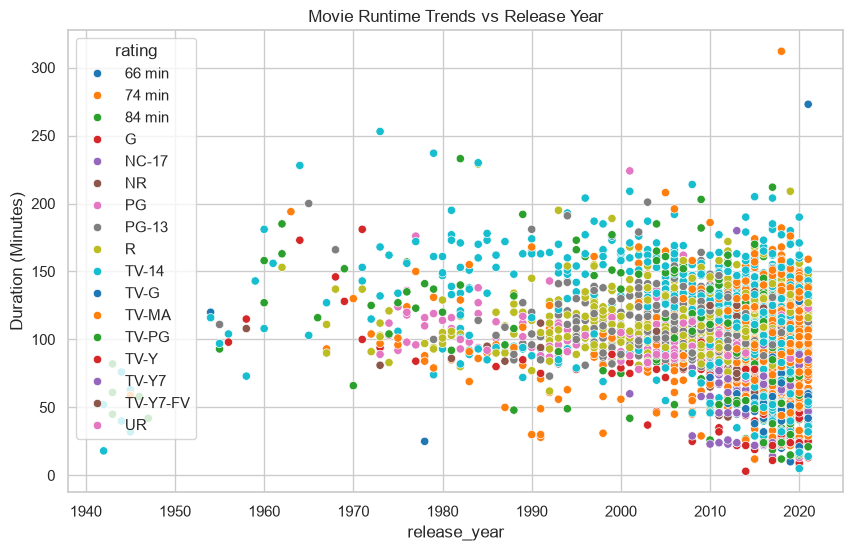

In [16]:
# Re-extract if structure changes occurred in previous operations
if 'duration_numeric' not in df.columns:
    df['duration_numeric'] = df['duration'].str.extract(r'(\d+)').astype(float)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df[df['type'] == 'Movie'], x='release_year', y='duration_numeric', hue='rating', palette='tab10')

plt.title('Movie Runtime Trends vs Release Year')
plt.ylabel('Duration (Minutes)')
plt.show()

### <span style="color:#00D2FF;">Q30. Write a Pandas method chain (starting with df) that drops rows missing a 'director', filters for 'Movies', groups by 'director', counts the titles, sorts descending, and returns the top 10 as a list.</span>

In [17]:
top_10_directors_list = (
    df.dropna(subset=['director'])
    .query("type == 'Movie'")
    .groupby('director')['show_id']
    .count()
    .nlargest(10)
    .index.tolist()
)

print("🎬 Top 10 Most Prolific Movie Directors:")
print(top_10_directors_list)

🎬 Top 10 Most Prolific Movie Directors:
['Rajiv Chilaka', 'Raúl Campos, Jan Suter', 'Suhas Kadav', 'Marcus Raboy', 'Jay Karas', 'Cathy Garcia-Molina', 'Jay Chapman', 'Martin Scorsese', 'Youssef Chahine', 'Steven Spielberg']


In [18]:
df.to_csv('netflix_titles_cleaned.csv', index=False)
print("✅ Cleaned dataset saved successfully as 'netflix_titles_cleaned.csv'!")

✅ Cleaned dataset saved successfully as 'netflix_titles_cleaned.csv'!
